In [1]:
!pip install pandas numpy scikit-learn mord openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
file_path = "./Post Methods Sheet.csv"

In [3]:
import os

print(os.getcwd())

for root, dirs, files in os.walk("."):
    if "Post Methods Sheet.csv" in files:
        print(os.path.join(root, "Post Methods Sheet.csv"))

/workspaces/BSAN-Project-2
./Post Methods Sheet.csv


In [4]:
%pip install pandas numpy matplotlib scikit-learn mord openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from mord import LogisticAT


# =========================
# 1. LOAD DATA
# =========================

file_path = "./Post Methods Sheet.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)


# =========================
# 2. CREATE POSITION GROUPS
# =========================

position_map = {
    "QB": "Skill", "RB": "Skill", "FB": "Skill", "WR": "Skill", "TE": "Skill",
    "OT": "OL", "OG": "OL", "G": "OL", "C": "OL", "OC": "OL", "IOL": "OL", "OL": "OL",
    "EDGE": "DL", "DE": "DL", "DT": "DL", "DL": "DL",
    "LB": "LB", "ILB": "LB", "OLB": "LB",
    "CB": "Secondary", "S": "Secondary", "SAF": "Secondary", "DB": "Secondary",
    "K": "Special Teams", "P": "Special Teams", "LS": "Special Teams"
}

df["Position Group"] = df["Position"].map(position_map).fillna(df["Position"])


# =========================
# 3. CREATE ORDINAL DRAFT TIER
# =========================

def draft_tier(pick):
    if pick <= 32:
        return "Round 1"
    elif pick <= 96:
        return "Rounds 2-3"
    elif pick <= 160:
        return "Rounds 4-5"
    elif pick <= 262:
        return "Rounds 6-7"
    else:
        return "Undrafted"

df["Draft Tier"] = df["Overall Pick"].apply(draft_tier)

labels_order = [
    "Round 1",
    "Rounds 2-3",
    "Rounds 4-5",
    "Rounds 6-7",
    "Undrafted"
]

tier_to_num = {
    "Round 1": 0,
    "Rounds 2-3": 1,
    "Rounds 4-5": 2,
    "Rounds 6-7": 3,
    "Undrafted": 4
}

num_to_tier = {
    0: "Round 1",
    1: "Rounds 2-3",
    2: "Rounds 4-5",
    3: "Rounds 6-7",
    4: "Undrafted"
}

df["Draft Tier Ordinal"] = df["Draft Tier"].map(tier_to_num)

print("\nDraft Tier Counts:")
print(df["Draft Tier"].value_counts())


# =========================
# 4. FEATURES
# ELO, School, and Arm Length excluded
# =========================

features = [
    "Season",
    "Position",
    "Position Group",
    "Conference",
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Combine Participation",
    "FPI",
    "Efficiencies Overall",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams",
    "CFP Appearance",
    "National Award"
]


# =========================
# 5. TRAIN 2023-2025, TEST 2026
# =========================

train_df = df[df["Season"].isin([2023, 2024, 2025])].copy()
test_df = df[df["Season"] == 2026].copy()

print("\nTraining rows:", len(train_df))
print("Testing rows:", len(test_df))

X_train = train_df[features]
y_train = train_df["Draft Tier Ordinal"]

X_test = test_df[features]
y_test = test_df["Draft Tier Ordinal"]


# =========================
# 6. BUILD MODEL
# =========================

def build_model(feature_list):
    categorical_features = [
        col for col in ["Position", "Position Group", "Conference"]
        if col in feature_list
    ]

    numeric_features = [
        col for col in feature_list if col not in categorical_features
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", "passthrough", numeric_features)
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("ordinal_model", LogisticAT(alpha=1.0))
        ]
    )

    return model


# =========================
# 7. MANUAL REPORT
# =========================

def print_manual_report(y_true, y_pred, title):
    y_true_labels = pd.Series(y_true).map(num_to_tier)
    y_pred_labels = pd.Series(y_pred).map(num_to_tier)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true_labels,
        y_pred_labels,
        labels=labels_order,
        zero_division=0
    )

    print(f"\n{title}")
    print(f"{'Tier':<14}{'Precision':>12}{'Recall':>12}{'F1-Score':>12}{'Support':>12}")

    for label, p, r, f, s in zip(labels_order, precision, recall, f1, support):
        print(f"{label:<14}{p:>12.2f}{r:>12.2f}{f:>12.2f}{s:>12}")

    print("\nAccuracy:", round(accuracy_score(y_true, y_pred), 4))

    ordinal_error = np.mean(np.abs(np.array(y_true) - np.array(y_pred)))
    print("Average Ordinal Error:", round(ordinal_error, 4))


# =========================
# 8. FIT MODEL AND PREDICT 2026
# =========================

overall_model = build_model(features)

overall_model.fit(X_train, y_train)

y_pred = overall_model.predict(X_test)

print_manual_report(
    y_test,
    y_pred,
    "2026 OUT-OF-SAMPLE ORDINAL PREDICTION REPORT"
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# =========================
# 9. FEATURE COEFFICIENTS
# =========================

ordinal_model = overall_model.named_steps["ordinal_model"]
feature_names = overall_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": ordinal_model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("\nTop 20 Features by Absolute Coefficient Size:")
print(importance_df.head(20).to_string(index=False))


# =========================
# 10. SAVE 2026 PLAYER PREDICTIONS
# =========================

results = test_df[
    [
        "Season",
        "Player",
        "Position",
        "Position Group",
        "Conference",
        "Overall Pick"
    ]
].copy()

results["Actual Tier Number"] = y_test.values
results["Predicted Tier Number"] = y_pred

results["Actual Tier"] = results["Actual Tier Number"].map(num_to_tier)
results["Predicted Tier"] = results["Predicted Tier Number"].map(num_to_tier)

results["Correct"] = np.where(
    results["Actual Tier Number"] == results["Predicted Tier Number"],
    "Correct",
    "Incorrect"
)

results["Ordinal Error"] = abs(
    results["Actual Tier Number"] - results["Predicted Tier Number"]
)

results.to_csv(
    "2026_out_of_sample_ordinal_predictions.csv",
    index=False
)

importance_df.to_csv(
    "2026_out_of_sample_feature_coefficients.csv",
    index=False
)

print("\nSaved:")
print("2026_out_of_sample_ordinal_predictions.csv")
print("2026_out_of_sample_feature_coefficients.csv")

print("\nSample Predictions:")
print(results.head(25).to_string(index=False))


# =========================
# 11. CHECK COEFFICIENTS AND THRESHOLDS
# =========================

print("\nNumber of coefficients:", len(ordinal_model.coef_))
print("Number of thresholds:", len(ordinal_model.theta_))

Dataset shape: (1272, 27)

Draft Tier Counts:
Draft Tier
Undrafted     347
Rounds 6-7    298
Rounds 2-3    252
Rounds 4-5    247
Round 1       128
Name: count, dtype: int64

Training rows: 965
Testing rows: 307

2026 OUT-OF-SAMPLE ORDINAL PREDICTION REPORT
Tier             Precision      Recall    F1-Score     Support
Round 1               0.50        0.38        0.43          32
Rounds 2-3            0.32        0.14        0.20          63
Rounds 4-5            0.23        0.33        0.27          61
Rounds 6-7            0.26        0.53        0.35          68
Undrafted             0.37        0.12        0.18          83

Accuracy: 0.2834
Average Ordinal Error: 1.0651

Confusion Matrix:
[[12  8  4  8  0]
 [ 5  9 19 27  3]
 [ 5  3 20 25  8]
 [ 1  4 21 36  6]
 [ 1  4 24 44 10]]

Top 20 Features by Absolute Coefficient Size:
                          Feature  Coefficient
              num__National Award    -2.507714
      num__40-Yard Dash (seconds)     0.692299
                 ca

In [6]:
y_prob = overall_model.predict_proba(X_test)

Dataset shape: (1272, 27)

Draft Tier Counts:
Draft Tier
Undrafted     347
Rounds 6-7    298
Rounds 2-3    252
Rounds 4-5    247
Round 1       128
Name: count, dtype: int64

Training rows: 965
Testing rows: 307

2026 OUT-OF-SAMPLE ORDINAL PREDICTION REPORT
Tier             Precision      Recall    F1-Score     Support
Round 1               0.50        0.38        0.43          32
Rounds 2-3            0.32        0.14        0.20          63
Rounds 4-5            0.23        0.33        0.27          61
Rounds 6-7            0.26        0.53        0.35          68
Undrafted             0.37        0.12        0.18          83

Accuracy: 0.2834
Average Ordinal Error: 1.0651

Confusion Matrix:
[[12  8  4  8  0]
 [ 5  9 19 27  3]
 [ 5  3 20 25  8]
 [ 1  4 21 36  6]
 [ 1  4 24 44 10]]

Top 20 Features by Absolute Coefficient Size:
                          Feature  Coefficient
              num__National Award    -2.507714
      num__40-Yard Dash (seconds)     0.692299
                 ca

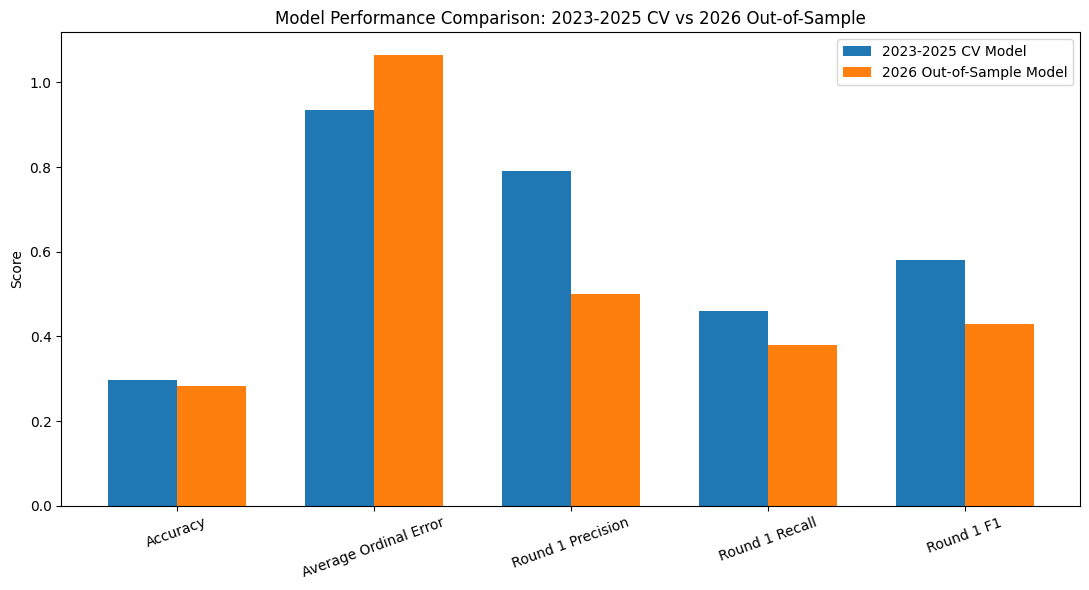

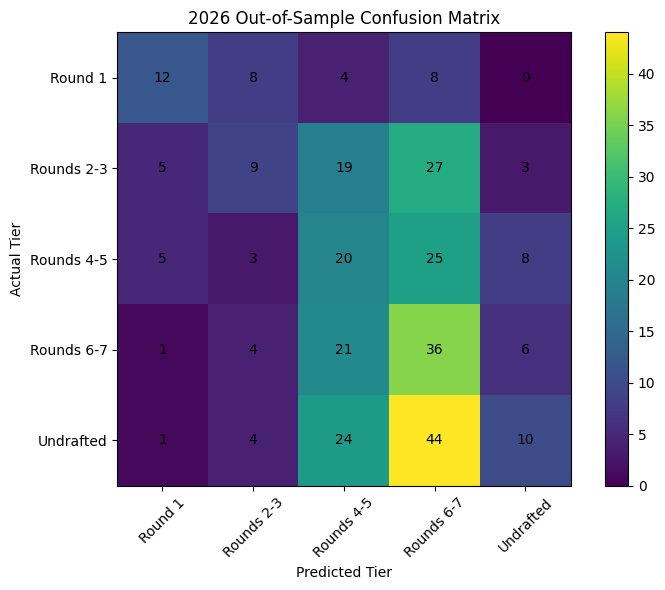

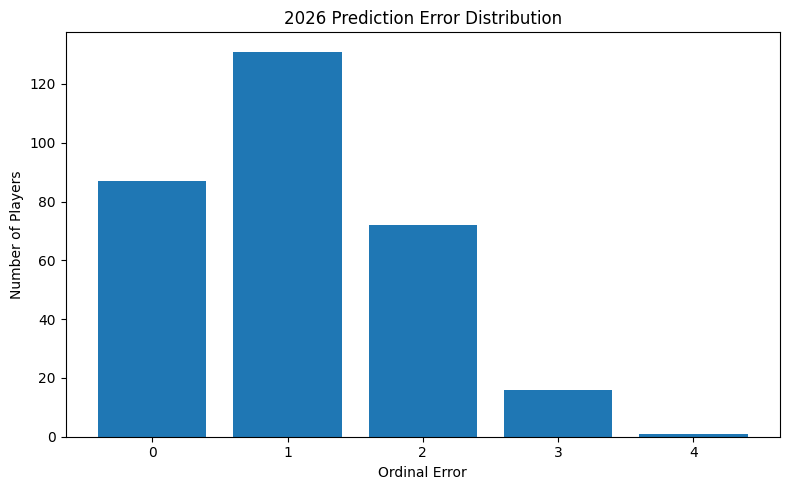

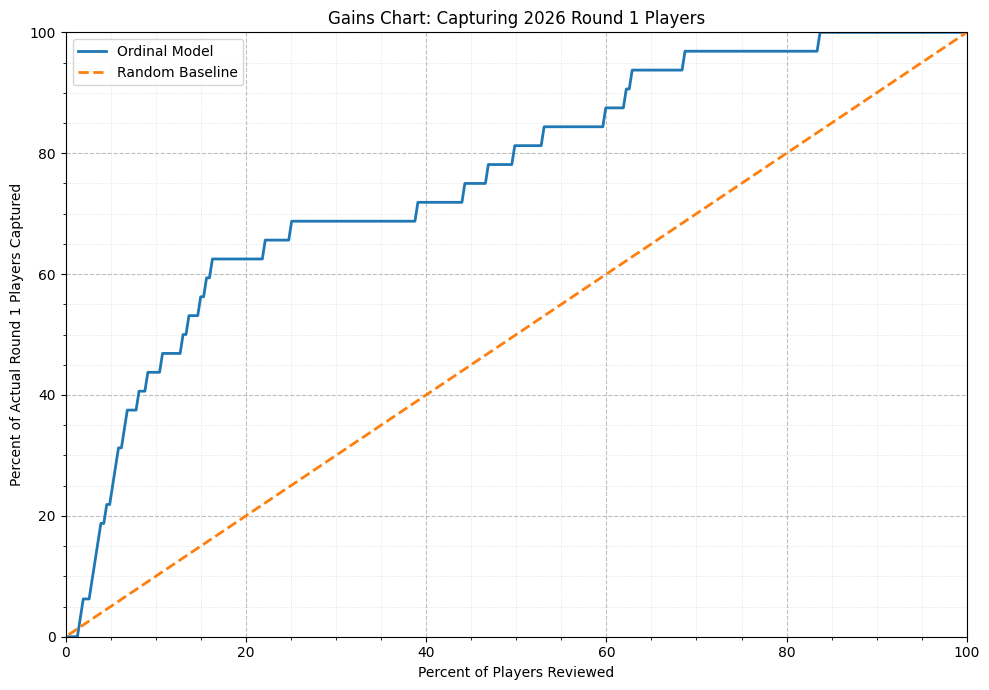

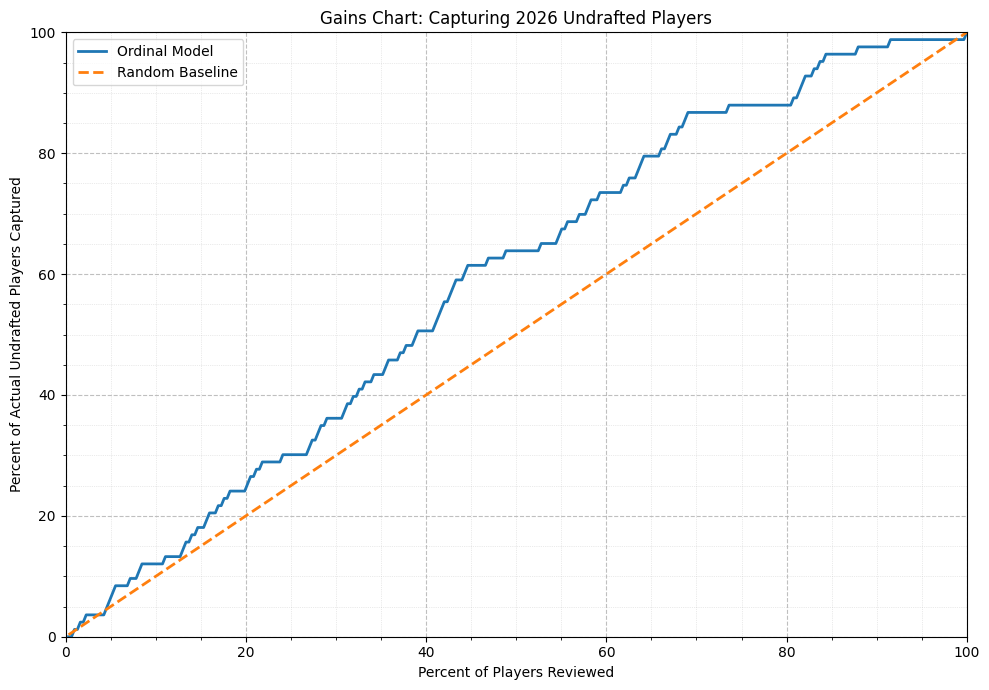


Top 40 Players by Round 1 Probability:
           Player Position Actual Tier Predicted Tier  Prob Round 1
     Joey Aguilar       QB   Undrafted        Round 1      0.884447
      Carson Beck       QB  Rounds 2-3        Round 1      0.837626
      Eli Stowers       TE  Rounds 2-3        Round 1      0.816576
      Red Murdock       LB  Rounds 6-7        Round 1      0.799548
  Francis Mauigoa       OT     Round 1        Round 1      0.765333
     Sonny Styles       LB     Round 1        Round 1      0.764505
     Jermod McCoy       CB  Rounds 4-5        Round 1      0.762478
   Malik Muhammad       CB  Rounds 4-5        Round 1      0.753432
    Kadyn Proctor       OT     Round 1        Round 1      0.706604
 Dillon Thieneman      SAF     Round 1        Round 1      0.690606
   Jeremiyah Love       RB     Round 1        Round 1      0.683187
     David Bailey     EDGE     Round 1        Round 1      0.671334
       LT Overton       DL  Rounds 4-5        Round 1      0.667262
     Spe

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from mord import LogisticAT


# =========================
# 1. LOAD DATA
# =========================

file_path = "./Post Methods Sheet.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)


# =========================
# 2. CREATE POSITION GROUPS
# =========================

position_map = {
    "QB": "Skill", "RB": "Skill", "FB": "Skill", "WR": "Skill", "TE": "Skill",
    "OT": "OL", "OG": "OL", "G": "OL", "C": "OL", "OC": "OL", "IOL": "OL", "OL": "OL",
    "EDGE": "DL", "DE": "DL", "DT": "DL", "DL": "DL",
    "LB": "LB", "ILB": "LB", "OLB": "LB",
    "CB": "Secondary", "S": "Secondary", "SAF": "Secondary", "DB": "Secondary",
    "K": "Special Teams", "P": "Special Teams", "LS": "Special Teams"
}

df["Position Group"] = df["Position"].map(position_map).fillna(df["Position"])


# =========================
# 3. CREATE DRAFT TIER
# =========================

def draft_tier(pick):
    if pick <= 32:
        return "Round 1"
    elif pick <= 96:
        return "Rounds 2-3"
    elif pick <= 160:
        return "Rounds 4-5"
    elif pick <= 262:
        return "Rounds 6-7"
    else:
        return "Undrafted"


df["Draft Tier"] = df["Overall Pick"].apply(draft_tier)

labels_order = [
    "Round 1",
    "Rounds 2-3",
    "Rounds 4-5",
    "Rounds 6-7",
    "Undrafted"
]

tier_to_num = {
    "Round 1": 0,
    "Rounds 2-3": 1,
    "Rounds 4-5": 2,
    "Rounds 6-7": 3,
    "Undrafted": 4
}

num_to_tier = {
    0: "Round 1",
    1: "Rounds 2-3",
    2: "Rounds 4-5",
    3: "Rounds 6-7",
    4: "Undrafted"
}

df["Draft Tier Ordinal"] = df["Draft Tier"].map(tier_to_num)

print("\nDraft Tier Counts:")
print(df["Draft Tier"].value_counts())


# =========================
# 4. FEATURES
# ELO, School, and Arm Length excluded
# =========================

features = [
    "Season",
    "Position",
    "Position Group",
    "Conference",
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Combine Participation",
    "FPI",
    "Efficiencies Overall",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams",
    "CFP Appearance",
    "National Award"
]


# =========================
# 5. TRAIN 2023-2025, TEST 2026
# =========================

train_df = df[df["Season"].isin([2023, 2024, 2025])].copy()
test_df = df[df["Season"] == 2026].copy()

print("\nTraining rows:", len(train_df))
print("Testing rows:", len(test_df))

X_train = train_df[features]
y_train = train_df["Draft Tier Ordinal"]

X_test = test_df[features]
y_test = test_df["Draft Tier Ordinal"]


# =========================
# 6. BUILD MODEL
# =========================

def build_model(feature_list):
    categorical_features = [
        col for col in ["Position", "Position Group", "Conference"]
        if col in feature_list
    ]

    numeric_features = [
        col for col in feature_list
        if col not in categorical_features
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", "passthrough", numeric_features)
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("ordinal_model", LogisticAT(alpha=1.0))
        ]
    )

    return model


# =========================
# 7. REPORT FUNCTION
# =========================

def print_manual_report(y_true, y_pred, title):
    y_true_labels = pd.Series(y_true).map(num_to_tier)
    y_pred_labels = pd.Series(y_pred).map(num_to_tier)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true_labels,
        y_pred_labels,
        labels=labels_order,
        zero_division=0
    )

    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

    print(f"{'Tier':<14}{'Precision':>12}{'Recall':>12}{'F1-Score':>12}{'Support':>12}")

    for label, p, r, f, s in zip(labels_order, precision, recall, f1, support):
        print(f"{label:<14}{p:>12.2f}{r:>12.2f}{f:>12.2f}{s:>12}")

    accuracy = accuracy_score(y_true, y_pred)
    ordinal_error = np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

    print("\nAccuracy:", round(accuracy, 4))
    print("Average Ordinal Error:", round(ordinal_error, 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


# =========================
# 8. FIT MODEL AND PREDICT 2026
# =========================

overall_model = build_model(features)

overall_model.fit(X_train, y_train)

y_pred = overall_model.predict(X_test)
y_prob = overall_model.predict_proba(X_test)

print_manual_report(
    y_test,
    y_pred,
    "2026 OUT-OF-SAMPLE ORDINAL PREDICTION REPORT"
)


# =========================
# 9. FEATURE COEFFICIENTS
# =========================

ordinal_model = overall_model.named_steps["ordinal_model"]
feature_names = overall_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": ordinal_model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("\nTop 20 Features by Absolute Coefficient Size:")
print(importance_df.head(20).to_string(index=False))


# =========================
# 10. CREATE RESULTS DATAFRAME
# =========================

results = test_df[
    [
        "Season",
        "Player",
        "Position",
        "Position Group",
        "Conference",
        "Overall Pick"
    ]
].copy().reset_index(drop=True)

results["Actual Tier Number"] = y_test.values
results["Predicted Tier Number"] = y_pred

results["Actual Tier"] = results["Actual Tier Number"].map(num_to_tier)
results["Predicted Tier"] = results["Predicted Tier Number"].map(num_to_tier)

results["Correct"] = np.where(
    results["Actual Tier Number"] == results["Predicted Tier Number"],
    "Correct",
    "Incorrect"
)

results["Ordinal Error"] = abs(
    results["Actual Tier Number"] - results["Predicted Tier Number"]
)


# =========================
# 11. ADD PREDICTED PROBABILITIES
# =========================

prob_df = pd.DataFrame(
    y_prob,
    columns=[
        "Prob Round 1",
        "Prob Rounds 2-3",
        "Prob Rounds 4-5",
        "Prob Rounds 6-7",
        "Prob Undrafted"
    ]
)

results = pd.concat(
    [results, prob_df],
    axis=1
)

# Prevent duplicate-column errors if notebook cells are rerun
results = results.loc[:, ~results.columns.duplicated()]


# =========================
# 12. SAVE BASE OUTPUTS
# =========================

results.to_csv(
    "2026_out_of_sample_predictions_with_probabilities.csv",
    index=False
)

importance_df.to_csv(
    "2026_out_of_sample_feature_coefficients.csv",
    index=False
)

print("\nSaved:")
print("2026_out_of_sample_predictions_with_probabilities.csv")
print("2026_out_of_sample_feature_coefficients.csv")


# =========================
# 13. METRIC COMPARISON CHART
# =========================

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Average Ordinal Error",
        "Round 1 Precision",
        "Round 1 Recall",
        "Round 1 F1"
    ],
    "2023-2025 CV Model": [
        0.2975,
        0.9339,
        0.79,
        0.46,
        0.58
    ],
    "2026 Out-of-Sample Model": [
        0.2834,
        1.0651,
        0.50,
        0.38,
        0.43
    ]
})

x = np.arange(len(metrics_df["Metric"]))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    metrics_df["2023-2025 CV Model"],
    width,
    label="2023-2025 CV Model"
)

plt.bar(
    x + width / 2,
    metrics_df["2026 Out-of-Sample Model"],
    width,
    label="2026 Out-of-Sample Model"
)

plt.xticks(x, metrics_df["Metric"], rotation=20)
plt.ylabel("Score")
plt.title("Model Performance Comparison: 2023-2025 CV vs 2026 Out-of-Sample")
plt.legend()
plt.tight_layout()

plt.savefig(
    "Metric_Comparison_Chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================
# 14. CONFUSION MATRIX VISUAL
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)

plt.title("2026 Out-of-Sample Confusion Matrix")
plt.xlabel("Predicted Tier")
plt.ylabel("Actual Tier")

plt.xticks(np.arange(len(labels_order)), labels_order, rotation=45)
plt.yticks(np.arange(len(labels_order)), labels_order)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()

plt.savefig(
    "2026_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================
# 15. ORDINAL ERROR DISTRIBUTION
# =========================

error_counts = results["Ordinal Error"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    error_counts.index.astype(str),
    error_counts.values
)

plt.xlabel("Ordinal Error")
plt.ylabel("Number of Players")
plt.title("2026 Prediction Error Distribution")
plt.tight_layout()

plt.savefig(
    "2026_Ordinal_Error_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================
# 16. GAINS CHART FUNCTION WITH GRIDLINES
# =========================

def plot_gains_chart(results_df, target_tier, probability_column, title, filename):

    temp = results_df.copy()

    # Prevent duplicate-column errors if notebook cells are rerun
    temp = temp.loc[:, ~temp.columns.duplicated()]

    temp["Actual Target"] = np.where(
        temp["Actual Tier"] == target_tier,
        1,
        0
    )

    temp = temp.sort_values(
        by=probability_column,
        ascending=False
    ).reset_index(drop=True)

    total_targets = temp["Actual Target"].sum()

    temp["Cumulative Targets Captured"] = (
        temp["Actual Target"].cumsum()
    )

    temp["Percent of Players Reviewed"] = (
        np.arange(1, len(temp) + 1) / len(temp)
    ) * 100

    temp["Percent of Actual Targets Captured"] = (
        temp["Cumulative Targets Captured"] / total_targets
    ) * 100

    plt.figure(figsize=(10, 7))

    plt.plot(
        temp["Percent of Players Reviewed"],
        temp["Percent of Actual Targets Captured"],
        linewidth=2,
        label="Ordinal Model"
    )

    plt.plot(
        temp["Percent of Players Reviewed"],
        temp["Percent of Players Reviewed"],
        linestyle="--",
        linewidth=2,
        label="Random Baseline"
    )

    plt.xlabel("Percent of Players Reviewed")
    plt.ylabel(
        f"Percent of Actual {target_tier} Players Captured"
    )
    plt.title(title)

    # Major gridlines
    plt.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.8,
        alpha=0.8
    )

    # Minor gridlines
    plt.minorticks_on()

    plt.grid(
        True,
        which="minor",
        linestyle=":",
        linewidth=0.5,
        alpha=0.5
    )

    plt.xlim(0, 100)
    plt.ylim(0, 100)

    plt.legend()
    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return temp


# =========================
# 17. ROUND 1 GAINS CHART
# =========================

round1_gains = plot_gains_chart(
    results_df=results,
    target_tier="Round 1",
    probability_column="Prob Round 1",
    title="Gains Chart: Capturing 2026 Round 1 Players",
    filename="2026_Round1_Gains_Chart.png"
)

round1_gains.to_csv(
    "2026_round1_gains_chart_data.csv",
    index=False
)


# =========================
# 18. UNDRAFTED GAINS CHART
# =========================

undrafted_gains = plot_gains_chart(
    results_df=results,
    target_tier="Undrafted",
    probability_column="Prob Undrafted",
    title="Gains Chart: Capturing 2026 Undrafted Players",
    filename="2026_Undrafted_Gains_Chart.png"
)

undrafted_gains.to_csv(
    "2026_undrafted_gains_chart_data.csv",
    index=False
)


# =========================
# 19. TOP-RANKED ROUND 1 PROSPECTS
# =========================

top_round1 = results.sort_values(
    by="Prob Round 1",
    ascending=False
).head(40)

print("\nTop 40 Players by Round 1 Probability:")
print(top_round1[
    [
        "Player",
        "Position",
        "Actual Tier",
        "Predicted Tier",
        "Prob Round 1"
    ]
].to_string(index=False))


# =========================
# 20. TOP-RANKED UNDRAFTED PROSPECTS
# =========================

top_undrafted = results.sort_values(
    by="Prob Undrafted",
    ascending=False
).head(40)

print("\nTop 40 Players by Undrafted Probability:")
print(top_undrafted[
    [
        "Player",
        "Position",
        "Actual Tier",
        "Predicted Tier",
        "Prob Undrafted"
    ]
].to_string(index=False))


# =========================
# 21. FINAL SAVE
# =========================

results.to_csv(
    "2026_final_predictions_visualized.csv",
    index=False
)

print("\nSaved:")
print("2026_final_predictions_visualized.csv")
print("2026_round1_gains_chart_data.csv")
print("2026_undrafted_gains_chart_data.csv")
print("2026_out_of_sample_feature_coefficients.csv")
print("Metric_Comparison_Chart.png")
print("2026_Confusion_Matrix.png")
print("2026_Ordinal_Error_Distribution.png")
print("2026_Round1_Gains_Chart.png")
print("2026_Undrafted_Gains_Chart.png")

In [8]:
# =========================
# DATASET SUMMARY
# =========================

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print(f"\nTotal Observations: {len(df):,}")
print(f"Training Observations (2023-2025): {len(train_df):,}")
print(f"Testing Observations (2026): {len(test_df):,}")

print(f"\nTotal Variables Used: {len(features)}")

print("\nVariables Used:")
for i, feature in enumerate(features, start=1):
    print(f"{i}. {feature}")


# =========================
# POSITION BREAKDOWN
# =========================

position_counts = (
    df["Position"]
    .value_counts()
    .sort_values(ascending=False)
)

print("\n" + "=" * 70)
print("POSITION BREAKDOWN")
print("=" * 70)

print(position_counts.to_string())

position_counts.to_csv(
    "Position_Breakdown.csv",
    header=["Count"]
)


# =========================
# POSITION GROUP BREAKDOWN
# =========================

position_group_counts = (
    df["Position Group"]
    .value_counts()
    .sort_values(ascending=False)
)

print("\n" + "=" * 70)
print("POSITION GROUP BREAKDOWN")
print("=" * 70)

print(position_group_counts.to_string())

position_group_counts.to_csv(
    "Position_Group_Breakdown.csv",
    header=["Count"]
)


# =========================
# CONFERENCE BREAKDOWN
# =========================

conference_counts = (
    df["Conference"]
    .value_counts()
    .sort_values(ascending=False)
)

print("\n" + "=" * 70)
print("CONFERENCE BREAKDOWN")
print("=" * 70)

print(conference_counts.to_string())

conference_counts.to_csv(
    "Conference_Breakdown.csv",
    header=["Count"]
)


# =========================
# DRAFT TIER BREAKDOWN
# =========================

draft_tier_counts = (
    df["Draft Tier"]
    .value_counts()
    .reindex(labels_order)
)

print("\n" + "=" * 70)
print("DRAFT TIER BREAKDOWN")
print("=" * 70)

print(draft_tier_counts.to_string())

draft_tier_counts.to_csv(
    "Draft_Tier_Breakdown.csv",
    header=["Count"]
)


# =========================
# TRAIN / TEST BREAKDOWN
# =========================

print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print("\nTraining Seasons:")
print(
    train_df["Season"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nTesting Seasons:")
print(
    test_df["Season"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nSaved:")
print("Position_Breakdown.csv")
print("Position_Group_Breakdown.csv")
print("Conference_Breakdown.csv")
print("Draft_Tier_Breakdown.csv")


DATASET SUMMARY

Total Observations: 1,272
Training Observations (2023-2025): 965
Testing Observations (2026): 307

Total Variables Used: 22

Variables Used:
1. Season
2. Position
3. Position Group
4. Conference
5. Height (inches)
6. Weight(lbs)
7. Hand (inches)
8. Wingspan (inches)
9. 40-Yard Dash (seconds)
10. Vertical (inches)
11. Bench (reps)
12. Broad Jump (inches)
13. 3-Cone (seconds)
14. Shuttle (seconds)
15. Combine Participation
16. FPI
17. Efficiencies Overall
18. Efficiencies Offense
19. Efficiencies Defense
20. Efficiencies SpecialTeams
21. CFP Appearance
22. National Award

POSITION BREAKDOWN
Position
WR      182
CB      167
EDGE    140
DL      114
RB      107
LB      106
OT      103
IOL      91
TE       84
QB       58
S        46
C        33
SAF      22
K        10
P         7
FB        1
LS        1

POSITION GROUP BREAKDOWN
Position Group
Skill            432
DL               254
Secondary        235
OL               227
LB               106
Special Teams     18

CONFE

In [9]:
# =========================
# NFL DRAFT ROUND BREAKDOWN
# =========================

def draft_round(pick):
    if pick <= 32:
        return "Round 1"
    elif pick <= 64:
        return "Round 2"
    elif pick <= 100:
        return "Round 3"
    elif pick <= 138:
        return "Round 4"
    elif pick <= 176:
        return "Round 5"
    elif pick <= 216:
        return "Round 6"
    elif pick <= 262:
        return "Round 7"
    else:
        return "Undrafted"

df["Draft Round"] = df["Overall Pick"].apply(draft_round)

round_order = [
    "Round 1",
    "Round 2",
    "Round 3",
    "Round 4",
    "Round 5",
    "Round 6",
    "Round 7",
    "Undrafted"
]

round_counts = (
    df["Draft Round"]
    .value_counts()
    .reindex(round_order)
)

print("\n" + "=" * 70)
print("DRAFT ROUND BREAKDOWN")
print("=" * 70)

print(round_counts.to_string())

round_counts.to_csv(
    "Draft_Round_Breakdown.csv",
    header=["Count"]
)

print("\nTotal Players:")
print(round_counts.sum())


DRAFT ROUND BREAKDOWN
Draft Round
Round 1      128
Round 2      128
Round 3      140
Round 4      147
Round 5      143
Round 6      124
Round 7      115
Undrafted    347

Total Players:
1272


In [10]:
# =========================
# DESCRIPTIVE STATISTICS
# =========================

numeric_columns = [
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Combine Participation",
    "FPI",
    "Efficiencies Overall",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams",
    "CFP Appearance",
    "National Award",
    "Overall Pick"
]

summary_stats = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std Dev": df[numeric_columns].std(),
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max()
})

summary_stats = summary_stats.round(3)

print("\n" + "=" * 90)
print("DESCRIPTIVE STATISTICS")
print("=" * 90)

print(summary_stats)

summary_stats.to_csv(
    "Descriptive_Statistics.csv"
)

print("\nSaved: Descriptive_Statistics.csv")


DESCRIPTIVE STATISTICS
                              Mean   Median  Std Dev  Minimum  Maximum
Height (inches)             74.254   74.375    3.173   65.000  134.750
Weight(lbs)                242.334  231.000   48.205  154.000  374.000
Hand (inches)                9.534    9.500    0.588    7.625   11.625
Wingspan (inches)           77.948   78.030    4.335   54.680  106.550
40-Yard Dash (seconds)       4.717    4.600    0.436    3.940   10.820
Vertical (inches)           34.399   34.500    5.062   20.500   68.290
Bench (reps)                22.139   21.000    8.308    8.000   82.000
Broad Jump (inches)        118.866  120.000   10.571   88.270  188.240
3-Cone (seconds)             7.332    7.170    1.039    4.600   22.540
Shuttle (seconds)            4.480    4.430    0.430    2.810    7.960
Combine Participation        0.794    1.000    0.405    0.000    1.000
FPI                         12.018   11.420    9.594  -19.353   31.487
Efficiencies Overall        69.413   70.238   15.613 